In [3]:
"""
INTEGRATED FIGURE 1: Complete Analysis Pipeline
Fixed version with proper execution order
"""

# %%
# =============================================================================
# IMPORTS AND CONFIGURATION
# =============================================================================
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import warnings
from scipy.sparse import csr_matrix
from scipy import stats
from datetime import datetime
from tqdm import tqdm

warnings.filterwarnings("ignore")

# Import ATSE coordination functions
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation') 
from ATSE_Coordination_Analysis_wQC import (
    perform_atse_qc,
    create_tissue_celltype_column
)

# Plotting configuration
sns.set_theme(context="notebook", style="white")
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 13,
    'axes.labelsize': 13,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'figure.titlesize': 12,
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.0,
    'axes.grid': False,
})


In [4]:
# %%
# =============================================================================
# DEFINE ALL ANALYSIS FUNCTIONS FIRST
# =============================================================================

def preprocess_data(adata, min_age=3):
    """Clean and prepare the data for analysis"""
    
    # Convert age to integers and define groups
    adata.obs["age"] = adata.obs["age"].str.replace("m", "").astype(int)

    # Filter for cells older than min_age
    adata = adata[adata.obs["age"] >= min_age].copy()
    print(f"Filtered {len(adata.obs)} cells to {len(adata.obs)} cells")
    
    # Define age groups
    adata.obs["age_group"] = adata.obs["age"].apply(
        lambda x: "young" if x in [2, 3] else "old" if x in [18, 24] else "other"
    )
    
    # Filter for cell types with sufficient cells
    counts = adata.obs.groupby(["broad_cell_type", "age"]).size().unstack(fill_value=0)
    counts_filtered = counts.drop(columns=[2], errors='ignore')  # Remove 2-month
    valid_celltypes = counts_filtered.apply(lambda row: (row >= 50).sum() >= 2, axis=1)
    valid_celltype_list = counts_filtered[valid_celltypes].index.tolist()
    
    adata = adata[adata.obs["broad_cell_type"].isin(valid_celltype_list)].copy()
    print(f"Retained {len(valid_celltype_list)} cell types with {adata.n_obs:,} cells")
    
    return adata

def calculate_psi_values(adata):
    """Calculate junction usage ratios (PSI values)"""
    
    A = adata.layers["cell_by_junction_matrix"].tocsr()
    B = adata.layers["cell_by_cluster_matrix"].tocsr()
    
    # Safe division to get PSI values
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_data = np.true_divide(A.data, B.data)
        ratio_data[~np.isfinite(ratio_data)] = np.nan
    
    psi_matrix = csr_matrix((ratio_data, A.indices, A.indptr), shape=A.shape)
    adata.layers["psi"] = psi_matrix
    
    return adata

def plot_dataset_overview(adata, output_dir, today):
    """Simple summary of samples and cell counts"""
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Create tissue-cell type combinations if both columns exist
    if 'tissue' in adata.obs.columns and 'medium_cell_type' in adata.obs.columns:
        # Create tissue-cell type pairs
        adata.obs['tissue_celltype'] = (adata.obs['tissue'].astype(str) + '_' + 
                                       adata.obs['medium_cell_type'].astype(str))
        groupby_col = 'tissue_celltype'
        ylabel = "Tissue - Cell Type"
        title = "Cell Distribution by Tissue-Cell Type Pairs"
    elif 'tissue' in adata.obs.columns:
        groupby_col = 'tissue'
        ylabel = "Tissue"
        title = "Cell Distribution by Tissue"
    else:
        groupby_col = 'broad_cell_type'
        ylabel = "Cell Type"
        title = "Cell Distribution by Cell Type"
    
    # Left: Cell counts by age and the chosen grouping
    counts = adata.obs.groupby([groupby_col, "age_group"]).size().unstack(fill_value=0)
    
    # Only plot if we have both young and old data
    available_ages = [col for col in ["young", "old"] if col in counts.columns]
    if len(available_ages) > 0:
        counts[available_ages].plot(kind="barh", stacked=False, ax=axes[0], 
                                   color=["#4CAF50", "#FF5722"][:len(available_ages)])
    
    axes[0].set_xlabel("Number of Cells")
    axes[0].set_ylabel(ylabel)
    axes[0].set_title(title)
    axes[0].legend(title="Age Group")
    
    # Make y-axis labels smaller if there are many categories
    if len(counts) > 10:
        axes[0].tick_params(axis='y', labelsize=8)
    
    # Right: Total statistics
    stats_text = f"""Dataset Statistics:
    
Total Cells: {adata.n_obs:,}
Total Junctions: {adata.n_vars:,}
Cell Types: {adata.obs['broad_cell_type'].nunique()}
Young Cells (3mo): {(adata.obs['age'] == 3).sum():,}
Old Cells (18-24mo): {((adata.obs['age'] == 18) | (adata.obs['age'] == 24)).sum():,}
    """
    axes[1].text(0.1, 0.5, stats_text, transform=axes[1].transAxes, 
                 fontsize=12, verticalalignment='center')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/fig1a_dataset_overview_{today}.pdf", bbox_inches="tight")
    plt.show()
    
    return counts

def plot_global_aging_effects(adata, output_dir, today):
    """Show overall distribution of age-related splicing changes"""
    
    # Calculate mean PSI per junction for young vs old
    young_mask = adata.obs["age_group"] == "young"
    old_mask = adata.obs["age_group"] == "old"
    
    psi_young = np.nanmean(adata[young_mask].layers["psi"].toarray(), axis=0)
    print(f"Obtained mean PSI for young cells")
    psi_old = np.nanmean(adata[old_mask].layers["psi"].toarray(), axis=0)
    print(f"Obtained mean PSI for old cells")
    
    delta_psi_global = psi_old - psi_young
    
    # Filter out NaN values
    delta_psi_global = delta_psi_global[~np.isnan(delta_psi_global)]
    
    fig, ax = plt.subplots(figsize=(6, 4))
    
    # Histogram
    counts, bins, patches = ax.hist(delta_psi_global, bins=50, edgecolor='black', 
                                    alpha=0.7, color='steelblue')
    
    # Add vertical lines
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='No change')
    ax.axvline(0.05, color='red', linestyle=':', alpha=0.5)
    ax.axvline(-0.05, color='red', linestyle=':', alpha=0.5)
    
    # Statistics
    n_increased = np.sum(delta_psi_global > 0.05)
    n_decreased = np.sum(delta_psi_global < -0.05)
    
    ax.text(0.02, 0.95, f"Increased (ΔPSI > 0.05): {n_increased:,}", 
            transform=ax.transAxes, fontsize=10)
    ax.text(0.02, 0.90, f"Decreased (ΔPSI < -0.05): {n_decreased:,}", 
            transform=ax.transAxes, fontsize=10)
    
    ax.set_xlabel("ΔPSI (Old - Young)")
    ax.set_ylabel("Number of Junctions")
    ax.set_title("Global Age-Related Splicing Changes")
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/fig1b_global_delta_psi_{today}.pdf", bbox_inches="tight")
    plt.show()
    
    return delta_psi_global

def calculate_celltype_delta_psi(adata, use_tissue_celltype=False):
    """Calculate ΔPSI for each cell type or tissue-cell type combination"""
    
    # Determine which column to use for grouping
    if use_tissue_celltype and 'tissue_celltype' in adata.obs.columns:
        groupby_col = 'tissue_celltype'
        min_cells = 20  # Lower threshold for tissue-cell type combinations
        desc = "Processing tissue-cell types"
    else:
        groupby_col = 'broad_cell_type'
        min_cells = 50  # Higher threshold for broad cell types
        desc = "Processing cell types"
    
    results = []
    cell_types = adata.obs[groupby_col].unique()
    
    for ct in tqdm(cell_types, desc=desc):
        ct_data = adata[adata.obs[groupby_col] == ct]
        
        young_mask = ct_data.obs["age_group"] == "young"
        old_mask = ct_data.obs["age_group"] == "old"
        
        if young_mask.sum() < min_cells or old_mask.sum() < min_cells:
            continue
            
        psi_young = np.nanmean(ct_data[young_mask].layers["psi"].toarray(), axis=0)
        psi_old = np.nanmean(ct_data[old_mask].layers["psi"].toarray(), axis=0)
        
        delta_psi = psi_old - psi_young
        
        for j_idx, dpsi in enumerate(delta_psi):
            if not np.isnan(dpsi):
                results.append({
                    'cell_type': ct,
                    'junction_idx': j_idx,
                    'delta_psi': dpsi,
                    'n_cells_young': young_mask.sum(),
                    'n_cells_old': old_mask.sum()
                })
    
    return pd.DataFrame(results)

def plot_celltype_specific_changes(df, output_dir, today):
    """Visualize cell type-specific splicing changes"""
    
    # Calculate summary statistics per cell type
    summary = df.groupby('cell_type').agg({
        'delta_psi': ['mean', 'median', lambda x: (x.abs() > 0.05).sum()],
        'n_cells_young': 'first',
        'n_cells_old': 'first'
    }).reset_index()
    
    summary.columns = ['cell_type', 'mean_dpsi', 'median_dpsi', 'n_changed', 
                       'n_cells_young', 'n_cells_old']
    summary = summary.sort_values('n_changed', ascending=False)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Strip plot
    for i, ct in enumerate(summary['cell_type']):
        ct_data = df[df['cell_type'] == ct]['delta_psi']
        y_pos = [i] * len(ct_data)
        
        # Color by magnitude
        colors = ['red' if d > 0.05 else 'blue' if d < -0.05 else 'gray' 
                  for d in ct_data]
        
        ax.scatter(ct_data, y_pos, alpha=0.3, s=1, c=colors, rasterized=True)
    
    # Add reference lines
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.axvline(0.05, color='red', linestyle=':', alpha=0.5)
    ax.axvline(-0.05, color='blue', linestyle=':', alpha=0.5)
    
    # Labels
    ax.set_yticks(range(len(summary)))
    ax.set_yticklabels([f"{ct} (n={n:,})" for ct, n in 
                        zip(summary['cell_type'], summary['n_changed'])])
    ax.set_xlabel("ΔPSI (Old - Young)")
    ax.set_ylabel("Cell Type")
    ax.set_title("Cell Type-Specific Splicing Changes with Age")
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/fig1c_celltype_delta_psi_{today}.pdf", bbox_inches="tight")
    plt.show()
    
    return summary

def find_and_plot_examples(adata, celltype_delta_df, output_dir, today, n_examples=3, use_tissue_celltype=False):
    """Find and visualize specific junction examples"""
    
    # Find junctions with largest changes
    top_changes = celltype_delta_df.nlargest(n_examples, 'delta_psi')
    bottom_changes = celltype_delta_df.nsmallest(n_examples, 'delta_psi')
    
    examples = pd.concat([top_changes, bottom_changes])
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    # Determine which column to use for filtering
    if use_tissue_celltype and 'tissue_celltype' in adata.obs.columns:
        groupby_col = 'tissue_celltype'
    else:
        groupby_col = 'broad_cell_type'
    
    for idx, (_, example) in enumerate(examples.iterrows()):
        if idx >= 6:
            break
            
        # Get the actual PSI values
        ct = example['cell_type']
        j_idx = int(example['junction_idx'])
        
        ct_data = adata[adata.obs[groupby_col] == ct]
        
        # Get PSI values for young and old
        young_psi = ct_data[ct_data.obs["age_group"] == "young"].layers["psi"][:, j_idx].toarray().flatten()
        old_psi = ct_data[ct_data.obs["age_group"] == "old"].layers["psi"][:, j_idx].toarray().flatten()
        
        # Remove NaN values
        young_psi = young_psi[~np.isnan(young_psi)]
        old_psi = old_psi[~np.isnan(old_psi)]
        
        # Plot distributions
        axes[idx].hist(young_psi, bins=20, alpha=0.5, label='Young', color='green', density=True)
        axes[idx].hist(old_psi, bins=20, alpha=0.5, label='Old', color='red', density=True)
        
        axes[idx].axvline(np.mean(young_psi), color='green', linestyle='--', linewidth=2)
        axes[idx].axvline(np.mean(old_psi), color='red', linestyle='--', linewidth=2)
        
        axes[idx].set_title(f"{ct}\nΔPSI = {example['delta_psi']:.3f}")
        axes[idx].set_xlabel("PSI")
        axes[idx].set_ylabel("Density")
        axes[idx].legend()
    
    plt.suptitle("Example Junctions with Age-Related Changes", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/fig1e_examples_{today}.pdf", bbox_inches="tight")
    plt.show()


In [5]:
# Setup
today = datetime.now().strftime("%Y%m%d")
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"
output_dir = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper"

# Create subdirectory for this run
run_dir = f"{output_dir}/figure1_{today}"
os.makedirs(run_dir, exist_ok=True)
print(f"Saving all outputs to: {run_dir}")

Saving all outputs to: /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper/figure1_20250922


In [6]:
# =========================================================================
# PART 1: Load and Preprocess Data
# =========================================================================

print("\n" + "="*60)
print("PART 1: DATA LOADING AND PREPROCESSING")
print("="*60)

SPLICE_INPUT = f"{BASE_DIR}/MODEL_INPUT/072025/aligned_splicing_data_20250730_164104.h5ad"
ATSE_FILE_PATH = f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-07-01_00-02-00.txt.gz"

print("Loading data...")
splice_adata = ad.read_h5ad(SPLICE_INPUT)
atse_df = pd.read_csv(ATSE_FILE_PATH, sep="\t")
print(f"Loaded {splice_adata.n_obs:,} cells and {splice_adata.n_vars:,} junctions")

# Preprocess
splice_adata = preprocess_data(splice_adata)
splice_adata = calculate_psi_values(splice_adata)


PART 1: DATA LOADING AND PREPROCESSING
Loading data...
Loaded 137,936 cells and 124,378 junctions
Filtered 88628 cells to 88628 cells
Retained 17 cell types with 88,511 cells



PART 2: DESCRIPTIVE ANALYSES

--- Panel A: Dataset Overview ---


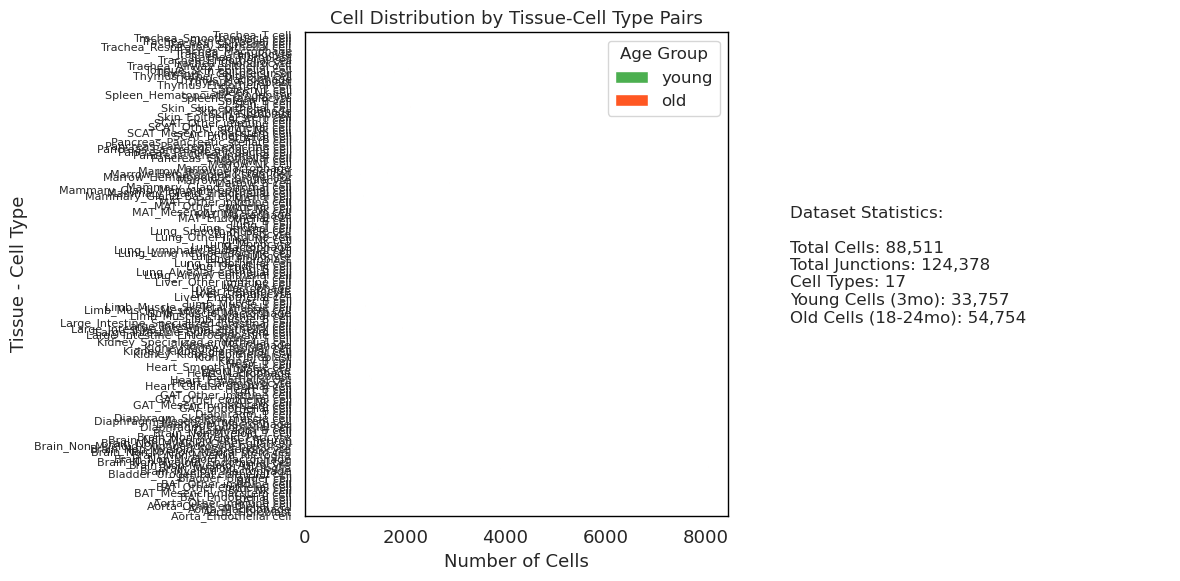


--- Panel B: Global Aging Effects ---
Obtained mean PSI for young cells
Obtained mean PSI for old cells


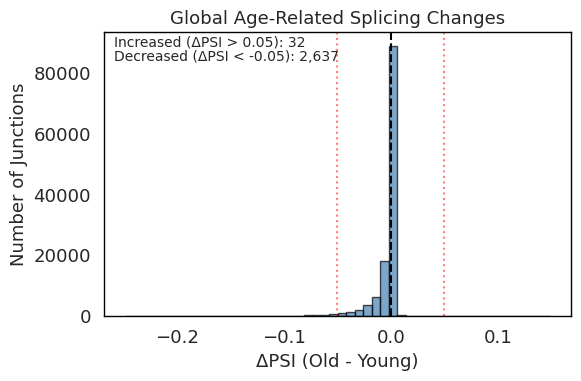


--- Panel C: Cell Type-Specific Patterns ---
Using tissue-cell type combinations: True


Processing tissue-cell types: 100%|██████████| 153/153 [09:14<00:00,  3.63s/it]


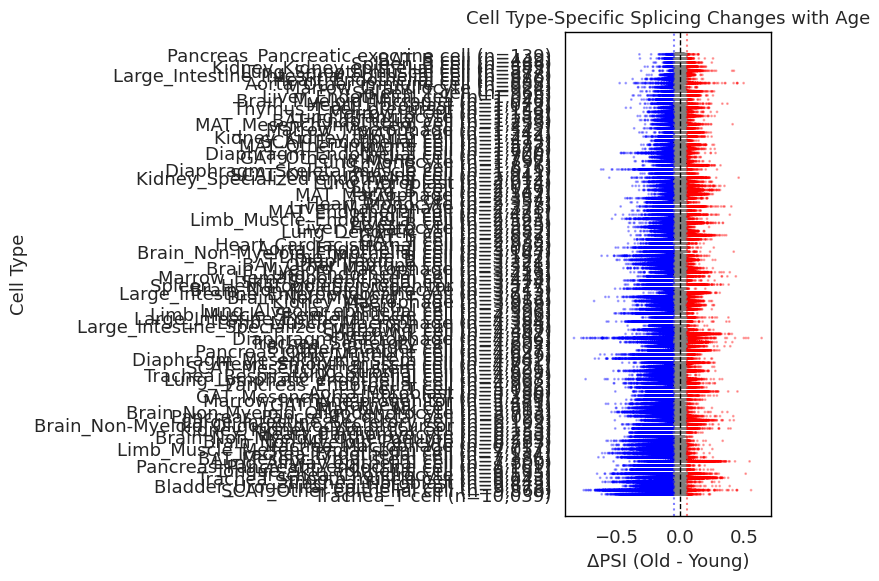

Saved cell type ΔPSI data: /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper/figure1_20250922/celltype_delta_psi_20250922.csv


In [7]:
# =========================================================================
# PART 2: Main Descriptive Analyses (Panels A-C)
# =========================================================================

print("\n" + "="*60)
print("PART 2: DESCRIPTIVE ANALYSES")
print("="*60)

# Panel A: Dataset Overview
print("\n--- Panel A: Dataset Overview ---")
dataset_counts = plot_dataset_overview(splice_adata, run_dir, today)

# Panel B: Global Aging Effects
print("\n--- Panel B: Global Aging Effects ---")
delta_psi_global = plot_global_aging_effects(splice_adata, run_dir, today)

# Panel C: Cell Type-Specific Patterns
print("\n--- Panel C: Cell Type-Specific Patterns ---")
# Use tissue-cell type combinations if available
use_tissue_celltype = 'tissue' in splice_adata.obs.columns and 'medium_cell_type' in splice_adata.obs.columns
print(f"Using tissue-cell type combinations: {use_tissue_celltype}")

celltype_delta_df = calculate_celltype_delta_psi(splice_adata, use_tissue_celltype=use_tissue_celltype)
celltype_summary = plot_celltype_specific_changes(celltype_delta_df, run_dir, today)

# Save intermediate results
celltype_delta_df.to_csv(f"{run_dir}/celltype_delta_psi_{today}.csv", index=False)
print(f"Saved cell type ΔPSI data: {run_dir}/celltype_delta_psi_{today}.csv")

In [9]:
# =========================================================================
# PART 3: ATSE Quality Control (Panel D)
# =========================================================================

print("\n" + "="*60)
print("PART 3: ATSE QUALITY CONTROL")
print("="*60)

# Run QC analysis
qc_df = perform_atse_qc(splice_adata, min_cells=50)
qc_df.to_csv(f"{run_dir}/atse_qc_results_{today}.csv", index=False)


PART 3: ATSE QUALITY CONTROL

STEP 1B: ATSE QUALITY CONTROL
Analyzing 25,128 ATSEs with 2-3 junctions


ATSE QC check:   0%|          | 0/25128 [00:00<?, ?it/s]

ATSE QC check:   0%|          | 50/25128 [00:59<8:18:43,  1.19s/it]


KeyboardInterrupt: 

In [ ]:
# Get per cell sum of PSI values... unlikely to be close to 1 because data is sparse... and not long read 
# For the actual QC should do across all cells within a given cell type 
# Mainly probelamtic if sum is great than 1... 

In [ ]:
qc_df[qc_df["qc_status"] == "good"]

In [ ]:
splice_adata[:, splice_adata.var["event_id"] == "ENSMUSG00000003429.11_atse_2"].var

In [ ]:
# =========================================================================
# PART 4: ATSE Coordination Analysis (Panel E)
# =========================================================================
print("\n" + "="*60)
print("PART 4: ATSE COORDINATION ANALYSIS")
print("="*60)

# Decide on analysis level
use_tissue_celltype = False  # Keep simple for main figure
analysis_column = 'broad_cell_type'
print("Analyzing at broad cell type level")

# Run coordination analysis on good quality ATSEs
good_atses = qc_df[qc_df['qc_status'] == 'good']
coord_df = analyze_atse_coordination_by_celltype(splice_adata, good_atses, analysis_column)
coord_df.to_csv(f"{run_dir}/atse_coordination_results_{today}.csv", index=False)

# Create coordination figure
fig = plot_coordination_results(coord_df, run_dir, today)

In [ ]:
# Check what columns are available in the data
print("Available columns in splice_adata.obs:")
print(splice_adata.obs.columns.tolist())
print("\nSample of tissue and medium_cell_type data:")
if 'tissue' in splice_adata.obs.columns:
    print(f"Tissue unique values: {splice_adata.obs['tissue'].unique()}")
if 'medium_cell_type' in splice_adata.obs.columns:
    print(f"Medium cell type unique values: {splice_adata.obs['medium_cell_type'].unique()}")
print(f"Broad cell type unique values: {splice_adata.obs['broad_cell_type'].unique()}")


In [ ]:
# =========================================================================
# PART 5: Summary Statistics and Examples
# =========================================================================
print("\n" + "="*60)
print("PART 5: SUMMARY AND EXAMPLES")
print("="*60)

# Find specific examples
find_and_plot_examples(splice_adata, celltype_delta_df, run_dir, today, n_examples=3, use_tissue_celltype=use_tissue_celltype)

# Generate comprehensive summary
summary = {
    'Total Cells': splice_adata.n_obs,
    'Total Junctions': splice_adata.n_vars,
    'Cell Types Analyzed': splice_adata.obs['broad_cell_type'].nunique(),
    'Junctions with |ΔPSI| > 0.05': (celltype_delta_df['delta_psi'].abs() > 0.05).sum(),
    'Mean |ΔPSI|': celltype_delta_df['delta_psi'].abs().mean(),
    'Median |ΔPSI|': celltype_delta_df['delta_psi'].abs().median(),
    'ATSEs Analyzed': len(qc_df),
    'Good Quality ATSEs': (qc_df['qc_status'] == 'good').sum(),
}

# Add coordination results if available
if 'classification' in coord_df.columns:
    summary['ATSEs with Regulated Switches'] = (coord_df['classification'] == 'regulated_switch').sum()
    summary['ATSEs with Dysregulation'] = coord_df['classification'].isin(['sum_dysregulation', 'correlation_loss']).sum()

summary_df = pd.DataFrame(summary, index=[0]).T
summary_df.columns = ['Value']
summary_df.to_csv(f"{run_dir}/fig1_complete_summary_{today}.csv")

print("\n" + "="*60)
print("COMPLETE SUMMARY")
print("="*60)
print(summary_df)